# 스마트 창고 출고 지연 예측 — Model v5

**핵심 변경: 타겟 Lag 피처 추가**

상위권과의 RMSE 2배 격차 원인 — 타겟 자체의 시계열 자기상관을 피처로 활용하지 않음

| 피처 | 내용 |
|------|------|
| `target_lag1~3` | 직전 1~3 타임스텝의 실제 지연값 |
| `target_roll_mean3/5` | 과거 3/5 스텝 이동 평균 |
| `target_roll_std3` | 과거 3 스텝 표준편차 |

**Test 추론**: 타겟을 모르므로 타임스텝 순서대로 예측 → 이전 예측값을 다음 스텝의 lag로 사용 (Autoregressive)

## 0. 라이브러리 로드

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import optuna
from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED    = 42
N_FOLD  = 5
N_STEPS = 25
TARGET  = 'avg_delay_minutes_next_30m'
ID_COLS = ['ID', 'layout_id', 'scenario_id']

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

## 1. v2 최적 파라미터 입력

In [2]:
# ─── v2 Optuna best params 붙여넣기 ────────────────────────────
lgb_best = {'n_estimators': 700, 'learning_rate': 0.011479253721973068, 'max_depth': 7, 'num_leaves': 157, 'subsample': 0.9417089137635153, 'colsample_bytree': 0.7182509076515207, 'reg_alpha': 0.002313051327322259, 'reg_lambda': 0.007098159082336851, 'min_child_samples': 70, 'random_state': 42, 'verbose': -1, 'n_jobs': -1}
xgb_best = {'n_estimators': 1700, 'learning_rate': 0.010069367505586393, 'max_depth': 8, 'subsample': 0.7701921669162993, 'colsample_bytree': 0.6281558321428306, 'reg_alpha': 0.00681854496911729, 'reg_lambda': 5.936330336429031, 'min_child_weight': 17, 'gamma': 1.217006530058639, 'random_state': 42, 'verbosity': 0, 'n_jobs': -1, 'tree_method': 'hist', 'early_stopping_rounds': 100}
cat_best = {'iterations': 2000, 'learning_rate': 0.011496997241230818, 'depth': 10, 'l2_leaf_reg': 5.1253106234016546, 'bagging_temperature': 0.04857511330881678, 'random_strength': 0.002172876360345995, 'border_count': 56, 'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 100, 'task_type': 'CPU'}
# ────────────────────────────────────────────────────────────────
print('파라미터 설정 완료')

파라미터 설정 완료


## 2. 데이터 로드 및 기본 전처리

In [3]:
train  = pd.read_csv('./open/train.csv')
test   = pd.read_csv('./open/test.csv')
layout = pd.read_csv('./open/layout_info.csv')

train = train.merge(layout, on='layout_id', how='left')
test  = test.merge(layout,  on='layout_id', how='left')

le = LabelEncoder()
train['layout_type'] = le.fit_transform(train['layout_type'].astype(str))
test['layout_type']  = le.transform(test['layout_type'].astype(str))

train = train.sort_values(['scenario_id', 'shift_hour']).reset_index(drop=True)
test  = test.sort_values(['scenario_id',  'shift_hour']).reset_index(drop=True)

print(f'train: {train.shape} / test: {test.shape}')

train: (250000, 108) / test: (50000, 107)


## 3. 입력 피처 엔지니어링 (v2 동일)

In [4]:
ts_features = [
    'order_inflow_15m', 'robot_utilization', 'congestion_score',
    'fault_count_15m',  'loading_dock_util', 'battery_mean',
    'blocked_path_15m', 'task_reassign_15m', 'low_battery_ratio',
    'avg_trip_distance',
]

def make_ts_features(df, cols, group_col='scenario_id'):
    df = df.copy()
    grp = df.groupby(group_col)
    for col in cols:
        for lag in [1, 2, 3]:
            df[f'{col}_lag{lag}'] = grp[col].shift(lag)
        for win in [3, 5]:
            df[f'{col}_roll_mean{win}'] = grp[col].transform(
                lambda x: x.shift(1).rolling(win, min_periods=1).mean())
            df[f'{col}_roll_std{win}'] = grp[col].transform(
                lambda x: x.shift(1).rolling(win, min_periods=2).std())
        df[f'{col}_cumsum'] = grp[col].transform(lambda x: x.shift(1).cumsum())
    return df

def make_extra_features(df):
    df = df.copy()
    df['time_step']          = df.groupby('scenario_id').cumcount()
    df['robot_active_ratio'] = df['robot_active'] / (
        df['robot_active'] + df['robot_idle'] + df['robot_charging'] + 1e-6)
    df['battery_congestion'] = df['low_battery_ratio'] * df['congestion_score']
    df['urgent_volume']      = df['urgent_order_ratio'] * df['order_inflow_15m']
    df['fault_impact']       = df['fault_count_15m'] * df['avg_recovery_time']
    df['dock_stress']        = df['outbound_truck_wait_min'] * df['loading_dock_util']
    return df

train = make_ts_features(train, ts_features)
test  = make_ts_features(test,  ts_features)
train = make_extra_features(train)
test  = make_extra_features(test)

print(f'입력 피처 생성 완료 | train: {train.shape}')

입력 피처 생성 완료 | train: (250000, 194)


## 4. 타겟 Lag 피처 생성 (핵심 신규)

- **train**: 실제 타겟값을 scenario 내에서 shift → leakage 없음
- **test**: 타겟 미존재 → 추론 시 autoregressive로 채움 (여기서는 NaN으로 초기화)

In [5]:
TARGET_LAG_COLS = [
    'target_lag1', 'target_lag2', 'target_lag3',
    'target_roll_mean3', 'target_roll_mean5', 'target_roll_std3',
]

def make_target_lag_features(df, target_col, group_col='scenario_id'):
    """train용: 실제 타겟값으로 lag 생성"""
    df = df.copy()
    grp = df.groupby(group_col)[target_col]
    df['target_lag1'] = grp.shift(1)
    df['target_lag2'] = grp.shift(2)
    df['target_lag3'] = grp.shift(3)
    df['target_roll_mean3'] = grp.transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    df['target_roll_mean5'] = grp.transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    df['target_roll_std3']  = grp.transform(
        lambda x: x.shift(1).rolling(3, min_periods=2).std())
    return df

train = make_target_lag_features(train, TARGET)

# test는 NaN으로 초기화 (autoregressive 추론 시 채워짐)
for col in TARGET_LAG_COLS:
    test[col] = np.nan

feat_cols = [c for c in train.columns if c not in ID_COLS + [TARGET]]
X      = train[feat_cols]
y      = train[TARGET]
groups = train['scenario_id']

print(f'최종 피처 수: {len(feat_cols)}  (v2 대비 +{len(feat_cols) - 190}개)')
print(f'타겟 lag 피처: {TARGET_LAG_COLS}')

최종 피처 수: 196  (v2 대비 +6개)
타겟 lag 피처: ['target_lag1', 'target_lag2', 'target_lag3', 'target_roll_mean3', 'target_roll_mean5', 'target_roll_std3']


## 5. Group K-Fold 학습 (모델 저장)

In [6]:
gkf5 = GroupKFold(n_splits=N_FOLD)

def run_cv_save_models(model_fn, model_name, fit_kwargs_fn=None):
    """OOF 예측 + 각 fold 모델 저장 (test autoregressive 추론용)"""
    oof    = np.zeros(len(X))
    models = []
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(gkf5.split(X, y, groups)):
        X_tr, y_tr   = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        model = model_fn()
        kw    = fit_kwargs_fn(X_val, y_val) if fit_kwargs_fn else {}
        model.fit(X_tr, y_tr, **kw)

        oof[val_idx] = model.predict(X_val)
        models.append(model)

        score = rmse(y_val, oof[val_idx])
        fold_scores.append(score)
        print(f'  [{model_name}] Fold {fold+1}  RMSE: {score:.4f}')

    total = rmse(y, oof)
    print(f'  [{model_name}] OOF RMSE: {total:.4f}\n')
    return oof, models, total

In [7]:
print('=== LightGBM ===')
lgb_oof, lgb_models, lgb_score = run_cv_save_models(
    lambda: LGBMRegressor(**lgb_best), 'LGB',
    lambda xv, yv: {'eval_set': [(xv, yv)],
                    'callbacks': [lgb.early_stopping(100, verbose=False),
                                  lgb.log_evaluation(500)]})

=== LightGBM ===
[500]	valid_0's l2: 302.48
  [LGB] Fold 1  RMSE: 17.3407
[500]	valid_0's l2: 277.206
  [LGB] Fold 2  RMSE: 16.6243
[500]	valid_0's l2: 240.733
  [LGB] Fold 3  RMSE: 15.4868
[500]	valid_0's l2: 310.087
  [LGB] Fold 4  RMSE: 17.6052
[500]	valid_0's l2: 235.134
  [LGB] Fold 5  RMSE: 15.3287
  [LGB] OOF RMSE: 16.5034



In [8]:
print('=== XGBoost ===')
xgb_oof, xgb_models, xgb_score = run_cv_save_models(
    lambda: XGBRegressor(**xgb_best), 'XGB',
    lambda xv, yv: {'eval_set': [(xv, yv)], 'verbose': False})

=== XGBoost ===
  [XGB] Fold 1  RMSE: 17.4200
  [XGB] Fold 2  RMSE: 16.6275
  [XGB] Fold 3  RMSE: 15.4901
  [XGB] Fold 4  RMSE: 17.5822
  [XGB] Fold 5  RMSE: 15.4103
  [XGB] OOF RMSE: 16.5317



In [9]:
print('=== CatBoost ===')
cat_oof, cat_models, cat_score = run_cv_save_models(
    lambda: CatBoostRegressor(**cat_best), 'CAT',
    lambda xv, yv: {'eval_set': (xv, yv)})

=== CatBoost ===
  [CAT] Fold 1  RMSE: 17.5660
  [CAT] Fold 2  RMSE: 16.8054
  [CAT] Fold 3  RMSE: 15.5653
  [CAT] Fold 4  RMSE: 17.8453
  [CAT] Fold 5  RMSE: 15.3620
  [CAT] OOF RMSE: 16.6596



## 6. OOF 앙상블 평가

In [10]:
# Optuna 앙상블 가중치 최적화
def ens_objective(trial):
    w1 = trial.suggest_float('w_lgb', 0.0, 1.0)
    w2 = trial.suggest_float('w_xgb', 0.0, 1.0)
    w3 = trial.suggest_float('w_cat', 0.0, 1.0)
    s  = w1 + w2 + w3
    if s < 1e-6: return 1e9
    ens = (w1*lgb_oof + w2*xgb_oof + w3*cat_oof) / s
    return rmse(y, ens)

ens_study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
ens_study.optimize(ens_objective, n_trials=500, show_progress_bar=True)

bw    = ens_study.best_params
total = bw['w_lgb'] + bw['w_xgb'] + bw['w_cat']
w_lgb = bw['w_lgb'] / total
w_xgb = bw['w_xgb'] / total
w_cat = bw['w_cat'] / total

ens_oof   = w_lgb*lgb_oof + w_xgb*xgb_oof + w_cat*cat_oof
ens_score = rmse(y, ens_oof)

print('=' * 50)
print(f'LGB   OOF RMSE : {lgb_score:.4f}  (가중치: {w_lgb:.4f})')
print(f'XGB   OOF RMSE : {xgb_score:.4f}  (가중치: {w_xgb:.4f})')
print(f'CAT   OOF RMSE : {cat_score:.4f}  (가중치: {w_cat:.4f})')
print(f'앙상블 OOF RMSE : {ens_score:.4f}')
print(f'v2 대비 개선    : {21.2717 - ens_score:+.4f}')

  0%|          | 0/500 [00:00<?, ?it/s]

LGB   OOF RMSE : 16.5034  (가중치: 0.5418)
XGB   OOF RMSE : 16.5317  (가중치: 0.1973)
CAT   OOF RMSE : 16.6596  (가중치: 0.2609)
앙상블 OOF RMSE : 16.4661
v2 대비 개선    : +4.8056


## 7. Test Autoregressive 추론

타임스텝 순서대로 예측 → 이전 예측값을 다음 스텝 lag 피처로 사용

In [11]:
def ensemble_predict(X_df):
    """저장된 모든 fold 모델의 평균 예측"""
    pred = np.zeros(len(X_df))
    for m in lgb_models: pred += m.predict(X_df) / (N_FOLD * 3)
    for m in xgb_models: pred += m.predict(X_df) / (N_FOLD * 3)
    for m in cat_models: pred += m.predict(X_df) / (N_FOLD * 3)
    return pred


# test 복사본 (lag 피처를 순차적으로 업데이트)
test_work  = test.copy()
test_preds = np.zeros(len(test_work))

# 시나리오별 예측 이력
pred_hist = {sc: [] for sc in test_work['scenario_id'].unique()}

print('Autoregressive 추론 시작...')
for step in range(N_STEPS):
    step_mask = test_work['time_step'] == step
    step_idx  = test_work.index[step_mask]
    sc_vals   = test_work.loc[step_idx, 'scenario_id'].values

    # 이전 스텝 예측값으로 lag 피처 업데이트
    for i, (idx, sc) in enumerate(zip(step_idx, sc_vals)):
        hist = pred_hist[sc]
        n    = len(hist)
        if n >= 1:
            test_work.at[idx, 'target_lag1']      = hist[-1]
            test_work.at[idx, 'target_roll_mean3'] = np.mean(hist[-min(3, n):])
            test_work.at[idx, 'target_roll_mean5'] = np.mean(hist[-min(5, n):])
        if n >= 2:
            test_work.at[idx, 'target_lag2'] = hist[-2]
        if n >= 3:
            test_work.at[idx, 'target_lag3']     = hist[-3]
            test_work.at[idx, 'target_roll_std3'] = np.std(hist[-3:])

    # 현재 스텝 예측
    step_pred = ensemble_predict(test_work.loc[step_idx, feat_cols])
    test_preds[step_idx] = step_pred

    # 이력 업데이트
    for sc, pred in zip(sc_vals, step_pred):
        pred_hist[sc].append(pred)

    if (step + 1) % 5 == 0:
        print(f'  Step {step+1:2d}/{N_STEPS} 완료')

print('추론 완료!')

Autoregressive 추론 시작...
  Step  5/25 완료
  Step 10/25 완료
  Step 15/25 완료
  Step 20/25 완료
  Step 25/25 완료
추론 완료!


## 8. 성능 비교 및 제출 파일 생성

버전별 OOF RMSE 비교
  v1 앙상블                        : 21.3531  (+0.0814)
  v2 앙상블 (Optuna 튜닝)            : 21.2717  (+0.0000)
✓ v5 LGB                        : 16.5034  (-4.7683)
✓ v5 XGB                        : 16.5317  (-4.7400)
✓ v5 CAT                        : 16.6596  (-4.6121)
✓ v5 앙상블 (Optuna 가중)            : 16.4661  (-4.8056)


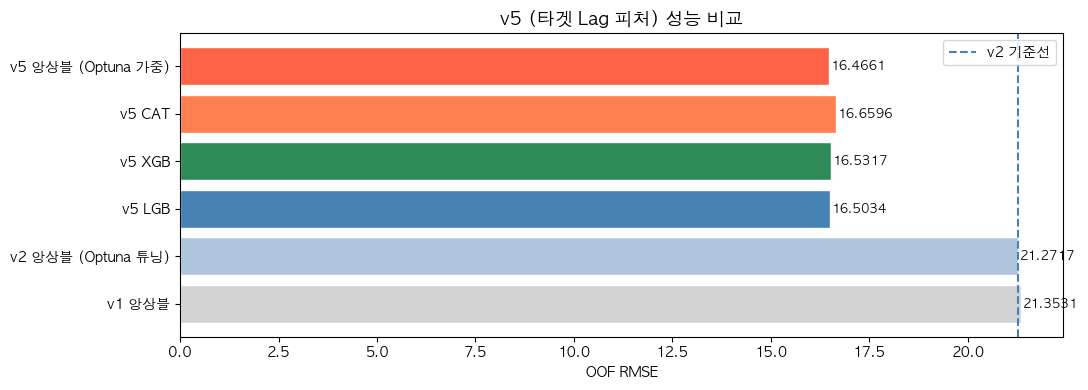

In [12]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

print('=' * 55)
print('버전별 OOF RMSE 비교')
print('=' * 55)
results = {
    'v1 앙상블': 21.3531,
    'v2 앙상블 (Optuna 튜닝)': 21.2717,
    'v5 LGB':  lgb_score,
    'v5 XGB':  xgb_score,
    'v5 CAT':  cat_score,
    'v5 앙상블 (Optuna 가중)': ens_score,
}
for name, score in results.items():
    delta = score - 21.2717
    mark  = '✓' if delta < 0 else ' '
    print(f'{mark} {name:30s}: {score:.4f}  ({delta:+.4f})')

colors = ['lightgray', 'lightsteelblue',
          'steelblue', 'seagreen', 'coral', 'tomato']
fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.barh(list(results.keys()), list(results.values()),
               color=colors, edgecolor='white')
for bar, score in zip(bars, results.values()):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=9)
ax.axvline(21.2717, color='steelblue', linestyle='--', lw=1.5, label='v2 기준선')
ax.set_xlabel('OOF RMSE')
ax.set_title('v5 (타겟 Lag 피처) 성능 비교', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
submission = pd.read_csv('./open/sample_submission.csv')
submission[TARGET] = test_preds
submission.to_csv('./submission_v5.csv', index=False)

print(f'submission_v5.csv 저장 완료  (OOF RMSE: {ens_score:.4f})')
print(f'v2 대비 개선: {21.2717 - ens_score:+.4f}')
print(submission[TARGET].describe().round(4))

submission_v5.csv 저장 완료  (OOF RMSE: 16.4661)
v2 대비 개선: +4.8056
count    50000.0000
mean        20.4092
std         13.1363
min          2.4286
25%          7.3581
50%         18.6342
75%         32.1090
max         69.3166
Name: avg_delay_minutes_next_30m, dtype: float64
